# 📊 Customer Churn & Retention Analysis

## 📌 Project Objective
Analyze customer churn behavior to identify key drivers of churn and provide actionable business insights.

---

## 📂 Dataset
Telco Customer Churn Dataset

---

## 🧠 Key Questions
- What percentage of customers churn?
- Which contract types have the highest churn?
- Do higher charges lead to churn?
- Does tenure influence retention?

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [66]:
df = pd.read_csv(r"C:\Users\dell\Documents\customer-churn-retention-analysis\data\raw\customer_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 🔍 1. Data Inspection
Understanding structure, missing values, and data types.

In [67]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [69]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [70]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## 🧹 2. Data Cleaning
Fixing data types and handling missing values.

In [71]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Convert Total Charges
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# Fill missing values
df['Total_Charges'].fillna(df['Total_Charges'].median(), inplace=True)

In [72]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Drop ID safely
df.drop(columns=['customerid'], errors='ignore', inplace=True)

# Convert churn safely
if 'churn' in df.columns:
    df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
else:
    print("⚠️ Churn column not found. Check column names.")

⚠️ Churn column not found. Check column names.


In [73]:
df.isnull().sum()

count                   0
country                 0
state                   0
city                    0
zip_code                0
lat_long                0
latitude                0
longitude               0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

## 📊 3. Exploratory Data Analysis (EDA)

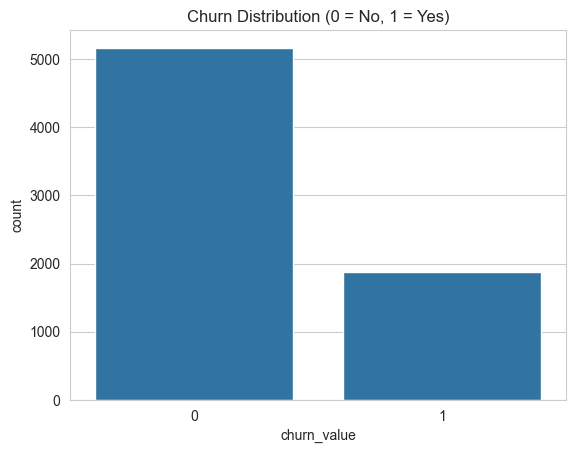

In [74]:
sns.countplot(x='churn_value', data=df)
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.show()

**Insight:** A significant portion of customers have churned, indicating a retention problem that needs attention.

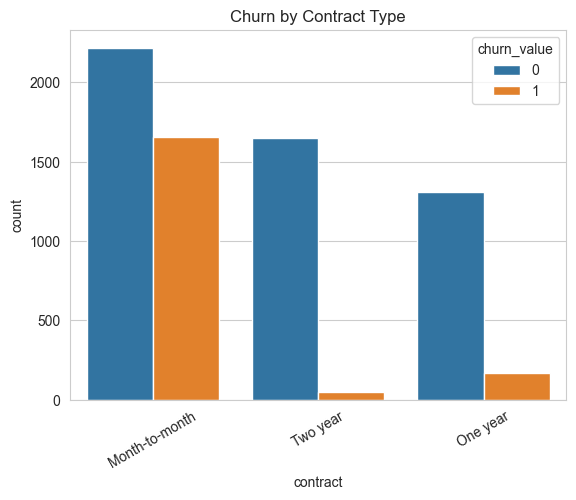

In [75]:
sns.countplot(x='contract', hue='churn_value', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

**Insight:** Customers on month-to-month contracts have the highest churn rate, while long-term contracts show better retention.

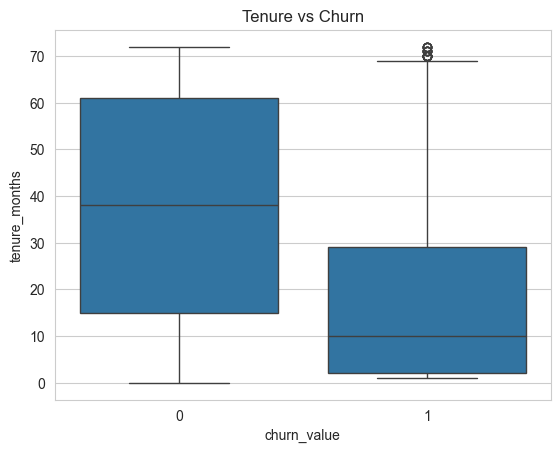

In [76]:
sns.boxplot(x='churn_value', y='tenure_months', data=df)
plt.title("Tenure vs Churn")
plt.show()

**Insight:** Customers with shorter tenure are more likely to churn, indicating early-stage dissatisfaction.

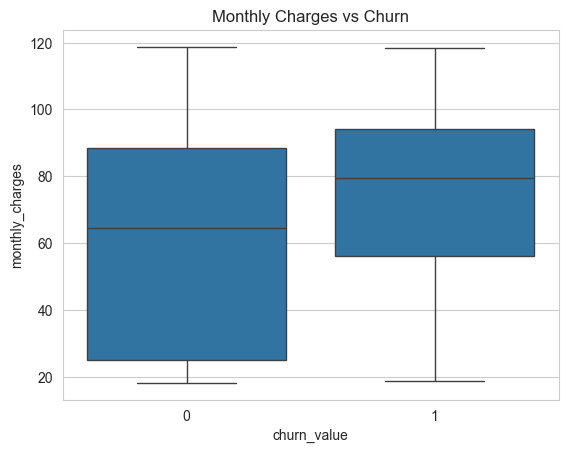

In [77]:
sns.boxplot(x='churn_value', y='monthly_charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:** Customers with higher monthly charges are more likely to churn.

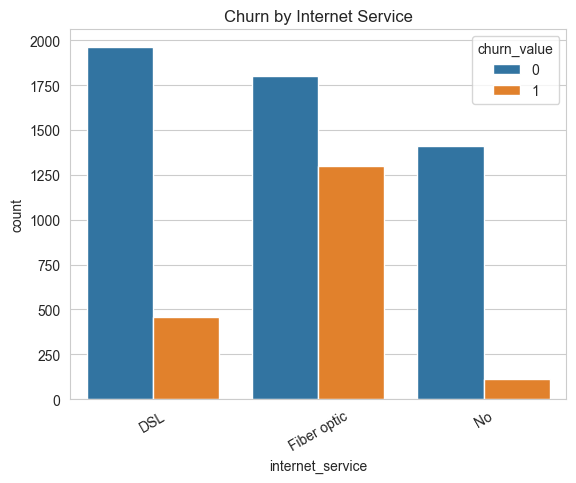

In [78]:
sns.countplot(x='internet_service', hue='churn_value', data=df)
plt.title("Churn by Internet Service")
plt.xticks(rotation=30)
plt.show()

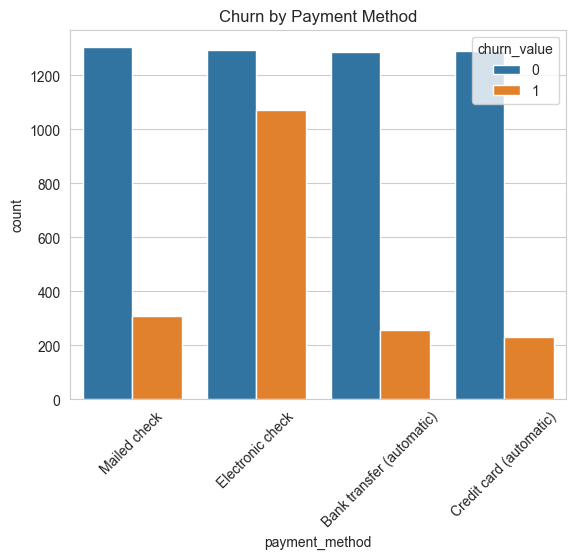

In [79]:
sns.countplot(x='payment_method', hue='churn_value', data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

**Insight:** Customers using electronic check payment methods show higher churn rates compared to other methods.

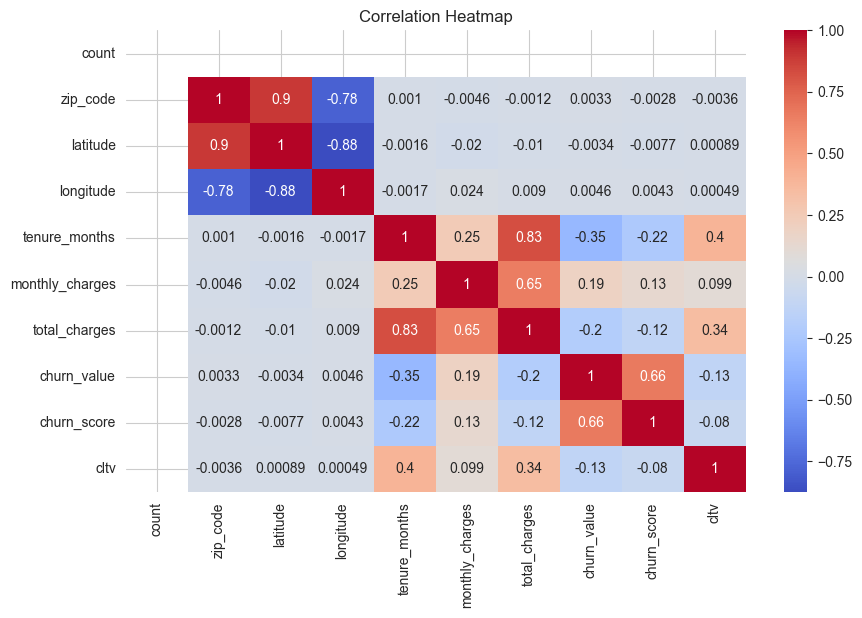

In [80]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Insight:** Monthly charges and tenure show noticeable relationships with churn, indicating they are key drivers.

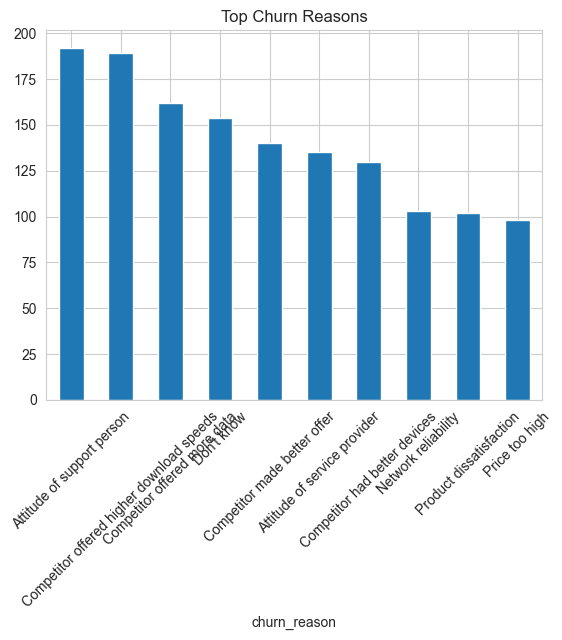

In [81]:
df['churn_reason'].value_counts().head(10).plot(kind='bar')
plt.title("Top Churn Reasons")
plt.xticks(rotation=45)
plt.show()

## 📌 Key Insights Summary

- High churn is observed among customers with month-to-month contracts
- Higher monthly charges are associated with increased churn
- Customers with shorter tenure are more likely to leave
- Payment method influences churn behavior

---

## 💡 Business Recommendations

- Encourage long-term contracts with discounts or incentives
- Review pricing strategy for high-charge customers
- Improve onboarding experience for new customers
- Promote more stable payment methods

In [82]:
df.to_csv(r"C:\Users\dell\Documents\customer-churn-retention-analysis\data\cleaned\customer_churn_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
